In [167]:
import matplotlib.pyplot as plt
import pandas as pd
from src import baseClasses, systemClasses, sensorClasses, muxClasses
import datetime
import numpy as np
from tqdm import tqdm
import pickle
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
from scipy.optimize import curve_fit

In [45]:
dataset = baseClasses.Data()

In [86]:
pipe = systemClasses.System(dataset=dataset, name="PIPE")
pp = systemClasses.System(dataset=dataset, name="PP")

Initializing PIPE Sensors: 100%|██████████| 12/12 [00:03<00:00,  3.63sensor/s]


ERROR: Channel (TE0120) not found


Initializing PP Sensors: 100%|██████████| 2/2 [00:00<00:00,  3.98sensor/s]


In [87]:
for id, sensor in pipe.sensors.items():
    print(id, sensor.name)
for id, sensor in pp.sensors.items():
    print(id, sensor.name)

49319 1-I
39671 1-U
39631 1-M
49320 2-I
37131 2-U
39670 2-M
49321 3-I
37136 3-U
37130 3-M
49322 4-I
39669 4-U
37133 4-M
37127 PP2
37142 PP1


In [217]:
mux1 = muxClasses.MUX(dataset=dataset, boardNumber=1)
mux2 = muxClasses.MUX(dataset=dataset, boardNumber=2)
mux3 = muxClasses.MUX(dataset=dataset, boardNumber=3)
mux4 = muxClasses.MUX(dataset=dataset, boardNumber=4)

In [103]:
ambient = systemClasses.System(dataset=dataset, name="AMBIENT")
print(ambient.sensors)

Initializing AMBIENT Sensors: 100%|██████████| 3/3 [00:00<00:00,  5.38sensor/s]

{1037: <src.sensorClasses.Sensor object at 0x7f2cb01dce20>, 1038: <src.sensorClasses.Sensor object at 0x7f2c5a8f00d0>, 1039: <src.sensorClasses.Sensor object at 0x7f2c59036730>}


(4.0276, 4.02925)

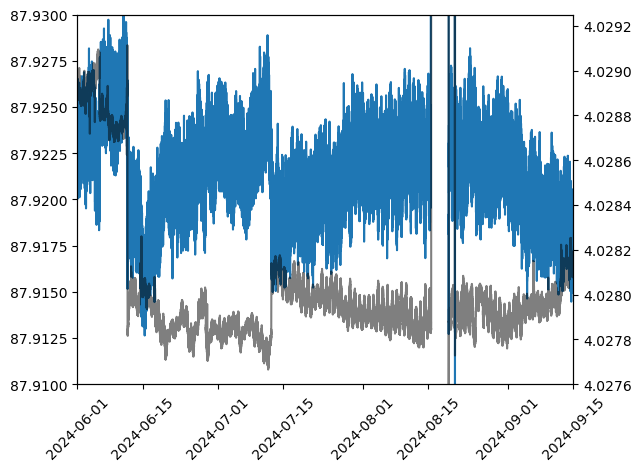

In [95]:
data_pre_correction = pipe.sensors[37136].data
fig, axes = plt.subplots(1,1)
# axes.plot(pipe.sensors[39671].data.index.values, pipe.sensors[39671].data.values, label=pipe.sensors[39671].name)
# axes.plot(pipe.sensors[37131].data.index.values, pipe.sensors[37131].data.values/mux3.data.values, label=pipe.sensors[37131].name)
axes.plot(data_pre_correction.index.values, data_pre_correction.values, label=pipe.sensors[37136].name)
# axes.plot(pipe.sensors[39669].data.index.values, pipe.sensors[39669].data.values, label=pipe.sensors[39669].name)
axes.set_ylim(87.91,87.93)
axes.set_xlim(datetime.datetime(2024, 6, 1), datetime.datetime(2024, 9, 15))
axes.tick_params(axis='x', rotation=45)
axes2 = axes.twinx()
axes2.plot(mux4.data.index.values, mux4.data.values, label=mux4.name, color='black', alpha=0.5)
axes2.set_ylim(4.0276, 4.02925)


In [96]:
pipe.calibrate(calibName="FIRST_POFF_TGRAD_APA_PP_PRM_PIPE_CE_OFF_REC_OFF_HV_OFF_20240502_094500_20240502_100000")
pp.calibrate(calibName="FIRST_POFF_TGRAD_APA_PP_PRM_PIPE_CE_OFF_REC_OFF_HV_OFF_20240502_094500_20240502_100000")

Equalizing PIPE Sensors:  92%|█████████▏| 11/12 [00:18<00:02,  2.79s/sensor]

ERROR: Channel (TE0120) not found


Equalizing PIPE Sensors: 100%|██████████| 12/12 [00:25<00:00,  2.15s/sensor]
Calibrating PIPE Sensors - Calibration Name: FIRST_POFF_TGRAD_APA_PP_PRM_PIPE_CE_OFF_REC_OFF_HV_OFF_20240502_094500_20240502_100000: 100%|██████████| 12/12 [00:01<00:00, 11.82sensor/s]
Equalizing PP Sensors: 100%|██████████| 2/2 [00:06<00:00,  3.39s/sensor]
Calibrating PP Sensors - Calibration Name: FIRST_POFF_TGRAD_APA_PP_PRM_PIPE_CE_OFF_REC_OFF_HV_OFF_20240502_094500_20240502_100000: 100%|██████████| 2/2 [00:00<00:00,  4.35sensor/s]


(4.0276, 4.02925)

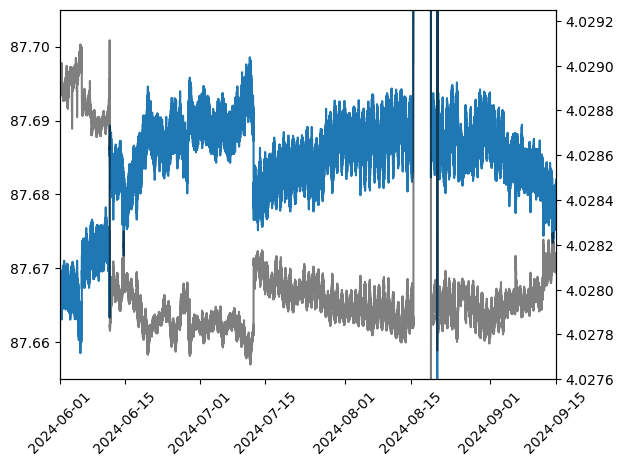

In [97]:
data_post_correction = pipe.sensors[37136].data
fig, axes = plt.subplots(1,1)
# axes.plot(pipe.sensors[39671].data.index.values, pipe.sensors[39671].data.values, label=pipe.sensors[39671].name)
# axes.plot(pipe.sensors[37131].data.index.values, pipe.sensors[37131].data.values/mux3.data.values, label=pipe.sensors[37131].name)
axes.plot(data_post_correction.index.values, data_post_correction.values, label=pipe.sensors[37136].name)
# axes.plot(pipe.sensors[39669].data.index.values, pipe.sensors[39669].data.values, label=pipe.sensors[39669].name)
axes.set_ylim(87.655,87.705)
axes.set_xlim(datetime.datetime(2024, 6, 1), datetime.datetime(2024, 9, 15))
axes.tick_params(axis='x', rotation=45)
axes2 = axes.twinx()
axes2.plot(mux4.data.index.values, mux4.data.values, label=mux4.name, color='black', alpha=0.5)
axes2.set_ylim(4.0276, 4.02925)


(87.655, 87.705)

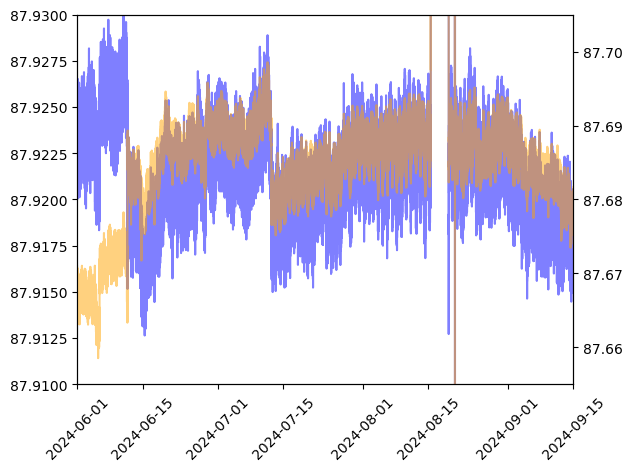

In [98]:
fig, axes = plt.subplots(1,1)
# axes.plot(pipe.sensors[39671].data.index.values, pipe.sensors[39671].data.values, label=pipe.sensors[39671].name)
# axes.plot(pipe.sensors[37131].data.index.values, pipe.sensors[37131].data.values/mux3.data.values, label=pipe.sensors[37131].name)
axes.plot(data_pre_correction.index.values, data_pre_correction.values, color="blue", alpha=0.5, label=pipe.sensors[37136].name)
# axes.plot(pipe.sensors[39669].data.index.values, pipe.sensors[39669].data.values, label=pipe.sensors[39669].name)
axes.set_ylim(87.91,87.93)
axes.set_xlim(datetime.datetime(2024, 6, 1), datetime.datetime(2024, 9, 15))
axes.tick_params(axis='x', rotation=45)
axes2 = axes.twinx()
axes2.plot(data_post_correction.index.values, data_post_correction.values, color="orange", alpha=0.5, label=pipe.sensors[37136].name)
axes2.set_ylim(87.655,87.705)


In [255]:
data_pre_correction_resampled = data_pre_correction.loc[(data_pre_correction.index>datetime.datetime(2024, 6, 1)) & (data_pre_correction.index<datetime.datetime(2024, 8, 10))].dropna().resample("3min").mean()
mux4.data = mux4.data.loc[(mux4.data.index>datetime.datetime(2024, 6, 1)) & (mux4.data.index<datetime.datetime(2024, 8, 10))].dropna().resample("3min").mean()
ambient_resampled = ambient.sensors[1037].data.loc[(ambient.sensors[1037].data.index>datetime.datetime(2024, 6, 1)) & (ambient.sensors[1037].data.index<datetime.datetime(2024, 8, 10))].dropna().resample("3min").mean()
humidity_resampled = ambient.sensors[1039].data.loc[(ambient.sensors[1039].data.index>datetime.datetime(2024, 6, 1)) & (ambient.sensors[1039].data.index<datetime.datetime(2024, 8, 10))].dropna().resample("3min").mean()

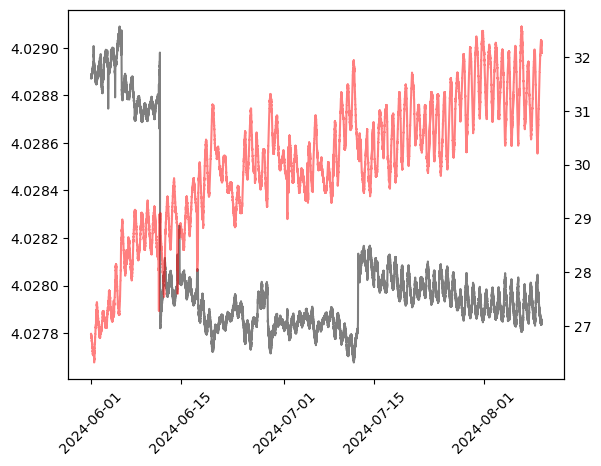

In [219]:
fig, axes = plt.subplots(1,1)
axes.plot(mux4.data.index.values, mux4.data.values, label=mux4.name, color='black', alpha=0.5)
axes.tick_params(axis='x', rotation=45)
axes2 = axes.twinx()
axes2.plot(ambient_resampled.index.values, ambient_resampled.values, label=ambient.sensors[1037].name, color='red', alpha=0.5)

Fit parameters: [-5.91838353e-05  4.02961841e+00]


Text(0, 0.5, 'MUX4 Temperature (C)')

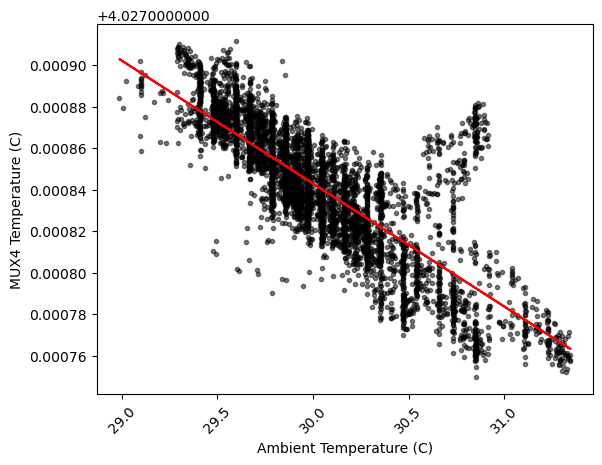

In [211]:
def line(x, A, B):
    return A * x + B
popt, pcov = curve_fit(line, ambient_resampled.values, mux4.data.values)
print("Fit parameters:", popt)

fig, axes = plt.subplots(1,1)
axes.plot(ambient_resampled.values, mux4.data.values, ".", label=mux4.name, color='black', alpha=0.5)
axes.tick_params(axis='x', rotation=45)
axes.plot(ambient_resampled.values, line(ambient_resampled.values, *popt), label="Fit", color='red')
axes.set_xlabel("Ambient Temperature (C)")
axes.set_ylabel("MUX4 Temperature (C)")

Fit parameters: [ 3.28729246 84.63348933]


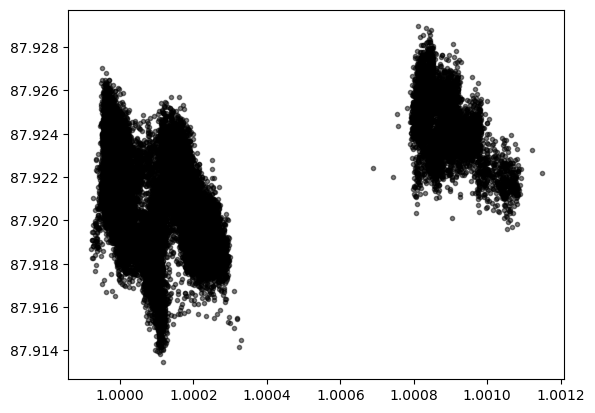

In [227]:
popt2, pcov2 = curve_fit(line, 1 + mux4.data.values - line(ambient_resampled.values, *popt), data_pre_correction_resampled.values)
print("Fit parameters:", popt2)
fig, axes = plt.subplots(1,1)
axes.plot(1 + mux4.data.values - line(ambient_resampled.values, *popt), data_pre_correction_resampled.values, ".", label=mux4.name, color='black', alpha=0.5)

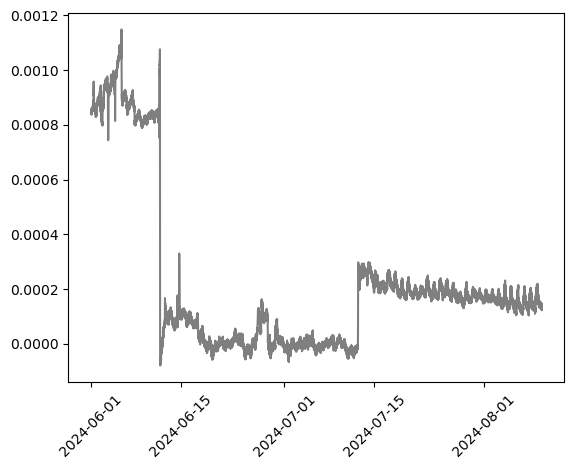

In [228]:
fig, axes = plt.subplots(1,1)
axes.plot(mux4.data.index.values, mux4.data.values - line(ambient_resampled.values, *popt), label=mux4.name, color='black', alpha=0.5)
axes.tick_params(axis='x', rotation=45)

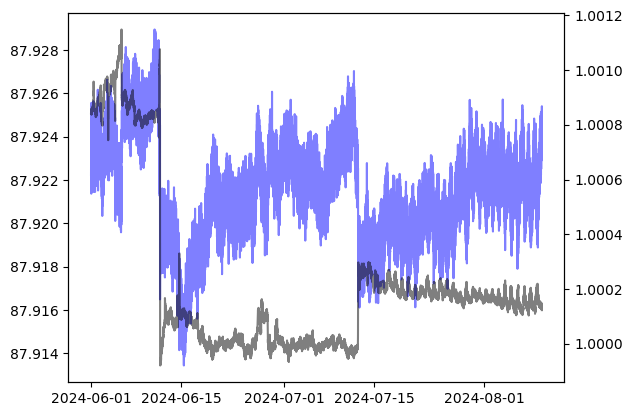

In [229]:
fig, axes = plt.subplots(1,1)
axes.plot(data_pre_correction_resampled.index.values, data_pre_correction_resampled.values, color="blue", alpha=0.5, label=pipe.sensors[37136].name)
axes2 = axes.twinx()
axes2.plot(mux4.data.index.values, 1 + mux4.data.values - line(ambient_resampled.values, *popt), label=mux4.name, color='black', alpha=0.5)

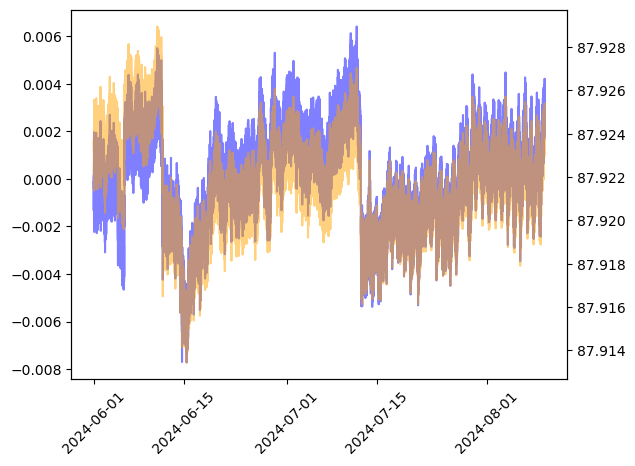

In [230]:
fig, axes = plt.subplots(1,1)
axes.plot(data_pre_correction_resampled.index.values, data_pre_correction_resampled.values - line((1 + mux4.data.values - line(ambient_resampled.values, *popt)), *popt2), color="blue", alpha=0.5, label=pipe.sensors[37136].name)
axes.tick_params(axis='x', rotation=45)
axes2 = axes.twinx()
axes2.plot(data_pre_correction_resampled.index.values, data_pre_correction_resampled.values, color="orange", alpha=0.5, label=pipe.sensors[37136].name)

Text(0.5, 1.0, 'After equalization & MUX correction')

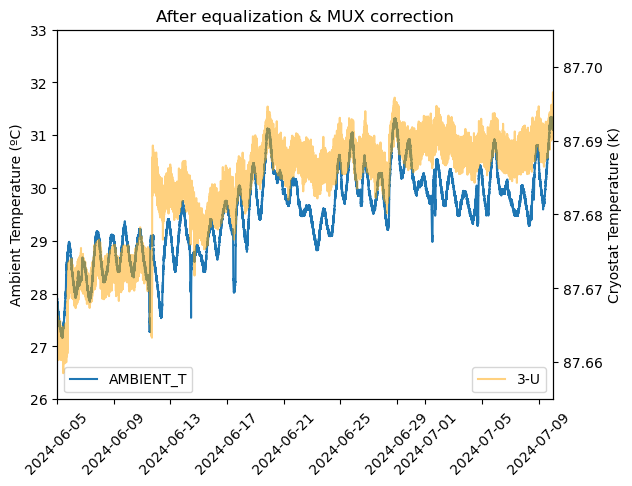

In [128]:
fig, axes = plt.subplots(1,1)
# axes.plot(pipe.sensors[39671].data.index.values, pipe.sensors[39671].data.values, label=pipe.sensors[39671].name)
# axes.plot(pipe.sensors[37131].data.index.values, pipe.sensors[37131].data.values/mux3.data.values, label=pipe.sensors[37131].name)
axes.plot(ambient.sensors[1037].data.index.values, ambient.sensors[1037].data.values, label=ambient.sensors[1037].name)
# axes.plot(pipe.sensors[39669].data.index.values, pipe.sensors[39669].data.values, label=pipe.sensors[39669].name)
axes.set_ylim(26,33)
axes.set_xlim(datetime.datetime(2024, 6, 5), datetime.datetime(2024, 7, 10))
axes.tick_params(axis='x', rotation=45)
axes2 = axes.twinx()
axes2.plot(data_post_correction.index.values, data_post_correction.values, color="orange", alpha=0.5, label=pipe.sensors[37136].name)
axes2.set_ylim(87.655,87.705)
axes.set_ylabel("Ambient Temperature (ºC)")
axes2.set_ylabel("Cryostat Temperature (K)")
axes.legend(loc="lower left")
axes2.legend(loc="lower right")
axes.set_title("After equalization & MUX correction")

In [272]:
data_post_correction_resampled = data_post_correction.loc[(data_post_correction.index>datetime.datetime(2024, 6, 15)) & (data_post_correction.index<datetime.datetime(2024, 7, 10))].dropna().resample("3min").mean()
ambient_resampled = ambient.sensors[1037].data.loc[(ambient.sensors[1037].data.index>datetime.datetime(2024, 6, 15)) & (ambient.sensors[1037].data.index<datetime.datetime(2024, 7, 10))].dropna().resample("3min").mean()
humidity_resampled = ambient.sensors[1038].data.loc[(ambient.sensors[1038].data.index>datetime.datetime(2024, 6, 15)) & (ambient.sensors[1038].data.index<datetime.datetime(2024, 7, 10))].dropna().resample("3min").mean()

Fit parameters: [4.33727144e-03 8.75579160e+01]


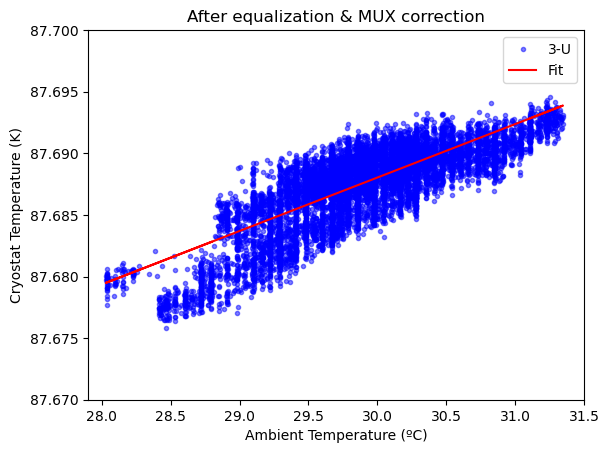

In [273]:
fig, axes = plt.subplots(1,1)
axes.plot(ambient_resampled.values, data_post_correction_resampled.values, ".", color="blue", alpha=0.5, label=pipe.sensors[37136].name)
axes.set_ylim(87.67,87.70)
axes.set_xlim(27.9,31.5)
axes.set_xlabel("Ambient Temperature (ºC)")
axes.set_ylabel("Cryostat Temperature (K)")
axes.set_title("After equalization & MUX correction")
popt, pcov = curve_fit(line, ambient_resampled.values, data_post_correction_resampled.values)
print("Fit parameters:", popt)
axes.plot(ambient_resampled.values, line(ambient_resampled.values, *popt), label="Fit", color='red')
axes.legend()

Text(0.5, 1.0, 'Equalization & MUX correction & Ambient correction')

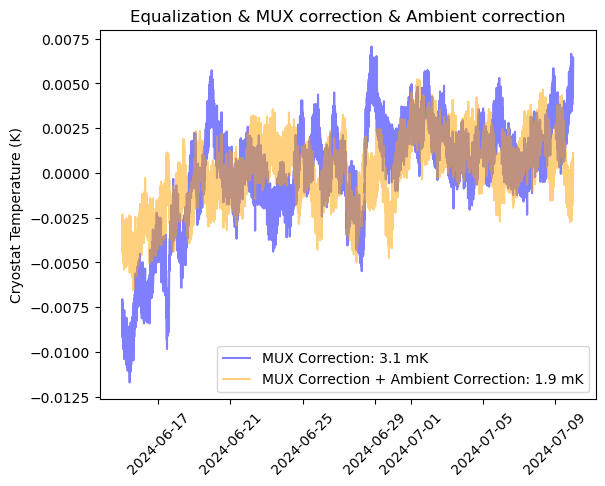

In [274]:
fig, axes = plt.subplots(1,1)
# axes.plot(pipe.sensors[39671].data.index.values, pipe.sensors[39671].data.values, label=pipe.sensors[39671].name)
# axes.plot(pipe.sensors[37131].data.index.values, pipe.sensors[37131].data.values/mux3.data.values, label=pipe.sensors[37131].name)
axes.plot(data_post_correction_resampled.index.values, data_post_correction_resampled.values - data_post_correction_resampled.mean(), color="blue", alpha=0.5, label=f"MUX Correction: { 1e3*data_post_correction_resampled.values.std():.1f} mK")
# axes.plot(pipe.sensors[39669].data.index.values, pipe.sensors[39669].data.values, label=pipe.sensors[39669].name)
# axes.set_xlim(datetime.datetime(2024, 6, 5), datetime.datetime(2024, 7, 10))
axes.tick_params(axis='x', rotation=45)
axes.plot(data_post_correction_resampled.index.values, data_post_correction_resampled.values - line(ambient_resampled.values, *popt), color="orange", alpha=0.5, label=fr"MUX Correction + Ambient Correction: {1e3*(data_post_correction_resampled.values - line(ambient_resampled.values, *popt)).std():.1f} mK")
# axes2.set_ylim(87.655,87.705)
axes.set_ylabel("Cryostat Temperature (K)")
axes.legend(loc="lower right")
axes.set_title("Equalization & MUX correction & Ambient correction")

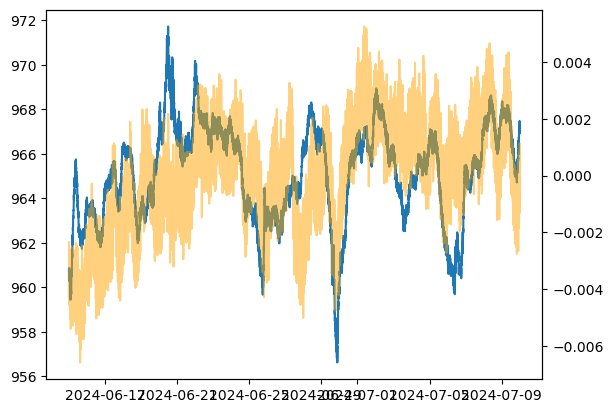

In [275]:
fig, axes = plt.subplots(1,1)
axes.plot(humidity_resampled.index.values, humidity_resampled.values, label=ambient.sensors[1039].name)
axes2 = axes.twinx()
axes2.plot(data_post_correction_resampled.index.values, data_post_correction_resampled.values - line(ambient_resampled.values, *popt), color="orange", alpha=0.5, label=fr"MUX Correction + Ambient Correction: {1e3*(data_post_correction_resampled.values - line(ambient_resampled.values, *popt)).std():.1f} mK")

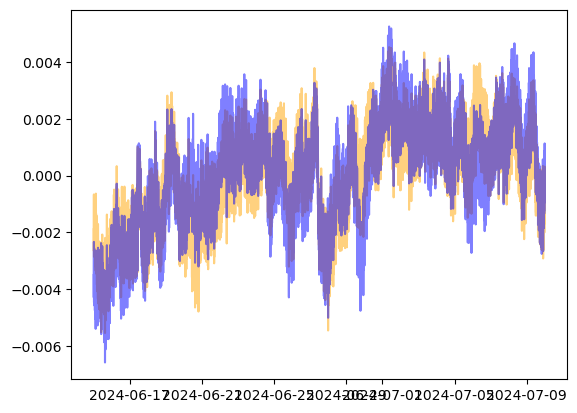

In [277]:
fig, axes = plt.subplots(1,1)
axes.plot(data_post_correction_resampled.index.values, (data_post_correction_resampled.values - line(ambient_resampled.values, *popt)) - line(humidity_resampled.values, *popt2), color="orange", alpha=0.5, label=fr"MUX Correction + Ambient Correction: {1e3*(data_post_correction_resampled.values - line(ambient_resampled.values, *popt)).std():.1f} mK")
axes.plot(data_post_correction_resampled.index.values, data_post_correction_resampled.values - line(ambient_resampled.values, *popt), color="blue", alpha=0.5, label=fr"MUX Correction + Ambient Correction: {1e3*(data_post_correction_resampled.values - line(ambient_resampled.values, *popt)).std():.1f} mK")